<a href="https://colab.research.google.com/github/anubhav123456/Deep-Learning/blob/main/4.%20Perceptron/Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Import Libraries

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np
import pandas as pd

# Step 2: Load Dataset

In [2]:
# Load Breast Cancer Dataset
breast_cancer_data = load_breast_cancer();

In [3]:
print("Feature Names:")
print(breast_cancer_data.feature_names)

print("\nTarget Names:")
print(breast_cancer_data.target_names)

Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Names:
['malignant' 'benign']


In [4]:
X = breast_cancer_data.data;        # Features
Y = breast_cancer_data.target;      # Labels (0 = Malignant, 1 = Benign)

In [5]:
print("Shape of X:", X.shape);
print("Shape of y:", Y.shape);

Shape of X: (569, 30)
Shape of y: (569,)


In [6]:
data = pd.DataFrame(data=X, columns=breast_cancer_data.feature_names);

In [7]:
data['class'] = Y;

In [8]:
display(data.head());

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [9]:
print(data['class'].value_counts());

class
1    357
0    212
Name: count, dtype: int64


In [10]:
print(breast_cancer_data.target_names);

['malignant' 'benign']


In [11]:
display(data.groupby('class').mean());

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
class,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


# Step 3: Train-Test Split

In [12]:
X = data.drop('class', axis=1);
Y = data['class'];

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, stratify=Y, random_state=42);

In [14]:
print("Inputs: ", X.shape, X_train.shape, X_test.shape);
print("Outputs: ", Y.shape, y_train.shape, y_test.shape);

Inputs:  (569, 30) (512, 30) (57, 30)
Outputs:  (569,) (512,) (57,)


# Plotting

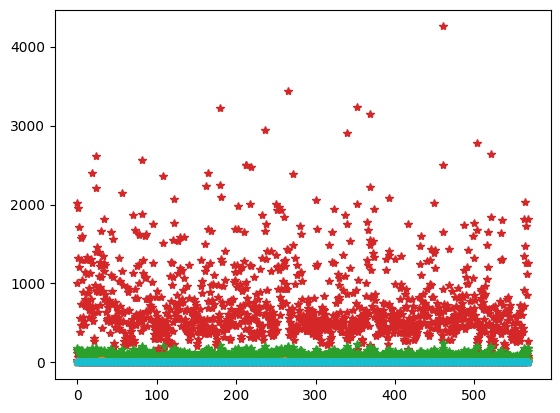

In [15]:
plt.plot(X, '*');
plt.show();

In [16]:
display(X_train.head());

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
413,14.99,22.11,97.53,693.7,0.08515,0.10250,0.06859,0.03876,0.1944,0.05913,...,16.76,31.55,110.20,867.1,0.1077,0.33450,0.3114,0.13080,0.3163,0.09251
517,19.89,20.26,130.50,1214.0,0.10370,0.13100,0.14110,0.09431,0.1802,0.06188,...,23.73,25.23,160.50,1646.0,0.1417,0.33090,0.4185,0.16130,0.2549,0.09136
245,10.48,19.86,66.72,337.7,0.10700,0.05971,0.04831,0.03070,0.1737,0.06440,...,11.48,29.46,73.68,402.8,0.1515,0.10260,0.1181,0.06736,0.2883,0.07748
102,12.18,20.52,77.22,458.7,0.08013,0.04038,0.02383,0.01770,0.1739,0.05677,...,13.34,32.84,84.58,547.8,0.1123,0.08862,0.1145,0.07431,0.2694,0.06878
28,15.30,25.27,102.40,732.4,0.10820,0.16970,0.16830,0.08751,0.1926,0.06540,...,20.27,36.71,149.30,1269.0,0.1641,0.61100,0.6335,0.20240,0.4027,0.09876


In [17]:
display(X_train.T.head());

,413,517,245,102,28,65,398,409,145,99,...,85,499,487,184,300,509,230,354,103,248
mean radius,14.99000,19.8900,10.480,12.18000,15.3000,14.7800,11.06000,12.27000,11.9000,14.42000,...,18.46000,20.5900,19.4400,15.28000,19.530,15.4600,17.0500,11.14000,9.8760,10.65000
mean texture,22.11000,20.2600,19.860,20.52000,25.2700,23.9400,14.83000,17.92000,14.6500,19.77000,...,18.52000,21.2400,18.8200,22.41000,18.900,23.9500,19.0800,14.07000,19.4000,25.22000
mean perimeter,97.53000,130.5000,66.720,77.22000,102.4000,97.4000,70.31000,78.41000,78.1100,94.48000,...,121.10000,137.8000,128.1000,98.92000,129.500,103.8000,113.4000,71.24000,63.9500,68.01000
mean area,693.70000,1214.0000,337.700,458.70000,732.4000,668.3000,378.20000,466.10000,432.8000,642.50000,...,1075.00000,1320.0000,1167.0000,710.60000,1217.000,731.3000,895.0000,384.60000,298.3000,347.00000
mean smoothness,0.08515,0.1037,0.107,0.08013,0.1082,0.1172,0.07741,0.08685,0.1152,0.09752,...,0.09874,0.1085,0.1089,0.09057,0.115,0.1183,0.1141,0.07274,0.1005,0.09657


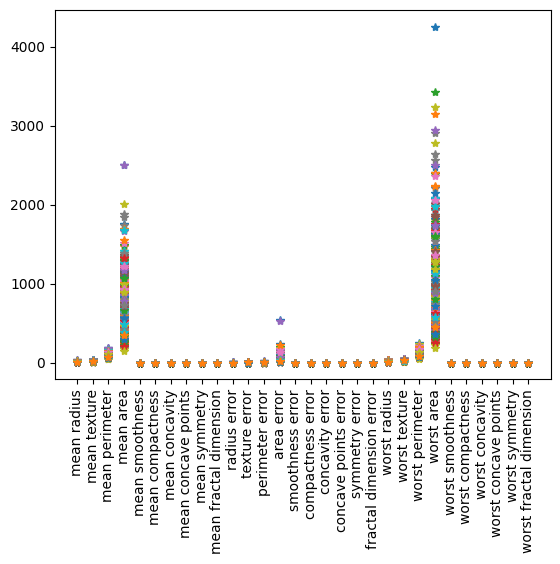

In [18]:
plt.plot(X_train.T, '*')
plt.xticks(rotation='vertical')
plt.show()

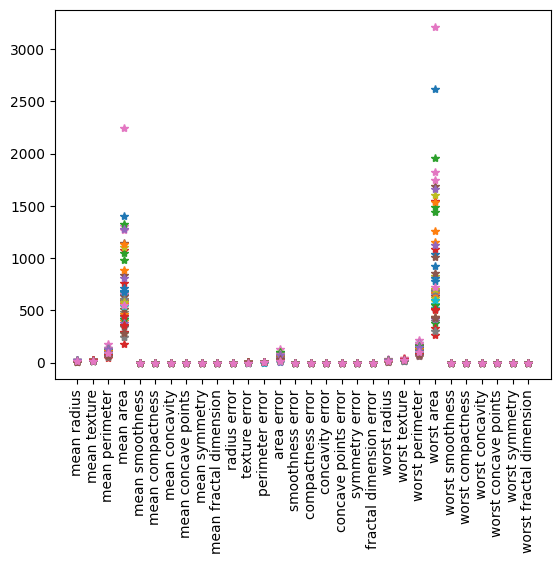

In [19]:
plt.plot(X_test.T, '*')
plt.xticks(rotation='vertical')
plt.show()

# Step 4: Dataframe to Numpy conversion

In [20]:
X_train = X_train.values;
y_train = y_train.values;
X_test = X_test.values;
y_test = y_test.values;

# Step 5: Model

In [21]:
class Perceptron:

    def __init__(self):
        self.w = None
        self.b = None

    def model(self, x):
        return 1 if (np.dot(self.w, x) >= self.b) else 0

    def predict(self, X):
        Y = []
        for x in X:
            result = self.model(x)
            Y.append(result)
        return np.array(Y)

    def fit(self, X, Y):

        self.w = np.ones(X.shape[1])
        self.b = 0

        for x, y in zip(X, Y):
            y_pred = self.model(x)
            if y == 1 and y_pred == 0:
                self.w = self.w + x
                self.b = self.b + 1
            elif y == 0 and y_pred == 1:
                self.w = self.w - x
                self.b = self.b - 1

    def accuracy(self, Y_pred, Y_true):
      return accuracy_score(Y_pred, Y_true);



# Step 6: Prediction

In [22]:
# 1. Instantiate the model
perceptron_neuron_model = Perceptron()

# 2. Train the model FIRST (this sets self.w and self.b)
perceptron_neuron_model.fit(X_train, y_train)

# 3. Now make predictions
y_pred_train = perceptron_neuron_model.predict(X_train)
y_pred_test = perceptron_neuron_model.predict(X_test)

In [23]:
train_accuracy = perceptron_neuron_model.accuracy(y_pred_train, y_train)
test_accuracy = perceptron_neuron_model.accuracy(y_pred_test, y_test)

print("Train Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

Train Accuracy : 0.90625
Test Accuracy  : 0.8947368421052632


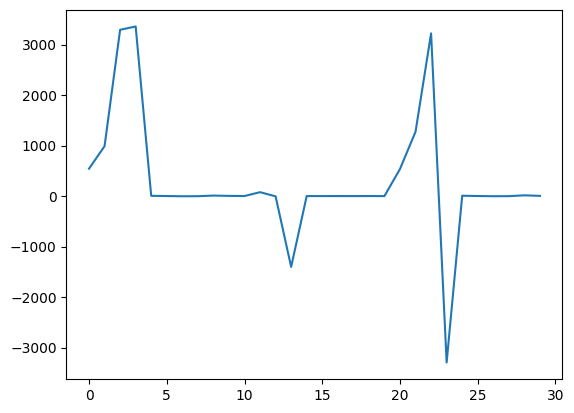

In [24]:
plt.plot(perceptron_neuron_model.w)
plt.show()

# Epochs

In [25]:
class Perceptron:

    def __init__(self):
        self.w = None
        self.b = None

    def model(self, x):
        return 1 if (np.dot(self.w, x) >= self.b) else 0

    def predict(self, X):
        Y = []
        for x in X:
            result = self.model(x)
            Y.append(result)
        return np.array(Y);

    def accuracy(self, Y_pred, Y_true):
      return accuracy_score(Y_pred, Y_true);

    def fit(self, X, Y, epochs = 1):

        self.w = np.ones(X.shape[1])
        self.b = 0

        accuracy = {};

        for epoch in range(epochs):
          print("Epoch: ", epoch + 1);
          for x, y in zip(X, Y):

            y_pred = self.model(x)
            if y == 1 and y_pred == 0:
              self.w = self.w + x
              self.b = self.b + 1
            elif y == 0 and y_pred == 1:
                self.w = self.w - x
                self.b = self.b - 1

          y_pred_train = self.predict(X);
          accuracy[epoch] = self.accuracy(y_pred_train, Y);
          print("Accuracy: ", accuracy[epoch]);

        max_accuracy_epoch = max(accuracy, key=accuracy.get);
        print("Max Accuracy: ", accuracy[max_accuracy_epoch]);
        print("Epoch: ", max_accuracy_epoch + 1);
        plt.plot(accuracy.values());
        plt.xlabel("Epochs");
        plt.ylabel("Accuracy");
        plt.show();




Epoch:  1
Accuracy:  0.90625
Epoch:  2
Accuracy:  0.919921875
Max Accuracy:  0.919921875
Epoch:  2


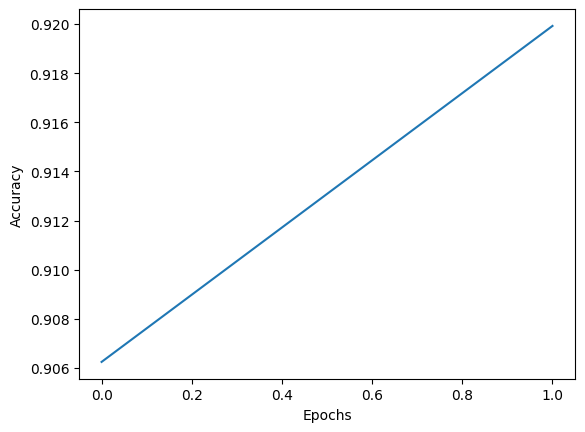

Train Accuracy : 0.919921875
Test Accuracy  : 0.8771929824561403


In [26]:
# 1. Instantiate the model
perceptron_neuron_model = Perceptron()

# 2. Train the model FIRST (this sets self.w and self.b)
perceptron_neuron_model.fit(X_train, y_train, epochs = 2);

# 3. Now make predictions
y_pred_train = perceptron_neuron_model.predict(X_train)
y_pred_test = perceptron_neuron_model.predict(X_test)

train_accuracy = perceptron_neuron_model.accuracy(y_pred_train, y_train)
test_accuracy = perceptron_neuron_model.accuracy(y_pred_test, y_test)

print("Train Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

Epoch:  1
Accuracy:  0.90625
Epoch:  2
Accuracy:  0.919921875
Epoch:  3
Accuracy:  0.916015625
Max Accuracy:  0.919921875
Epoch:  2


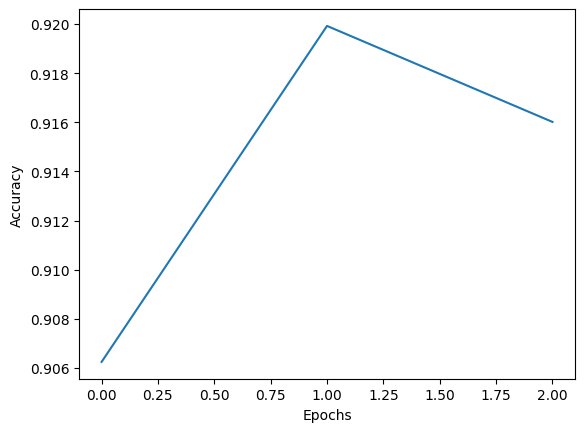

Train Accuracy : 0.916015625
Test Accuracy  : 0.8771929824561403


In [27]:
# 2. Train the model FIRST (this sets self.w and self.b)
perceptron_neuron_model.fit(X_train, y_train, epochs = 3);

# 3. Now make predictions
y_pred_train = perceptron_neuron_model.predict(X_train)
y_pred_test = perceptron_neuron_model.predict(X_test)

train_accuracy = perceptron_neuron_model.accuracy(y_pred_train, y_train)
test_accuracy = perceptron_neuron_model.accuracy(y_pred_test, y_test)

print("Train Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

Epoch:  1
Accuracy:  0.90625
Epoch:  2
Accuracy:  0.919921875
Epoch:  3
Accuracy:  0.916015625
Epoch:  4
Accuracy:  0.7265625
Epoch:  5
Accuracy:  0.798828125
Epoch:  6
Accuracy:  0.748046875
Epoch:  7
Accuracy:  0.765625
Epoch:  8
Accuracy:  0.8359375
Epoch:  9
Accuracy:  0.806640625
Epoch:  10
Accuracy:  0.78515625
Epoch:  11
Accuracy:  0.8203125
Epoch:  12
Accuracy:  0.826171875
Epoch:  13
Accuracy:  0.912109375
Epoch:  14
Accuracy:  0.91015625
Epoch:  15
Accuracy:  0.91015625
Epoch:  16
Accuracy:  0.83203125
Epoch:  17
Accuracy:  0.91015625
Epoch:  18
Accuracy:  0.908203125
Epoch:  19
Accuracy:  0.75
Epoch:  20
Accuracy:  0.748046875
Epoch:  21
Accuracy:  0.75390625
Epoch:  22
Accuracy:  0.7578125
Epoch:  23
Accuracy:  0.8671875
Epoch:  24
Accuracy:  0.751953125
Epoch:  25
Accuracy:  0.759765625
Epoch:  26
Accuracy:  0.873046875
Epoch:  27
Accuracy:  0.87109375
Epoch:  28
Accuracy:  0.869140625
Epoch:  29
Accuracy:  0.865234375
Epoch:  30
Accuracy:  0.87890625
Epoch:  31
Accuracy: 

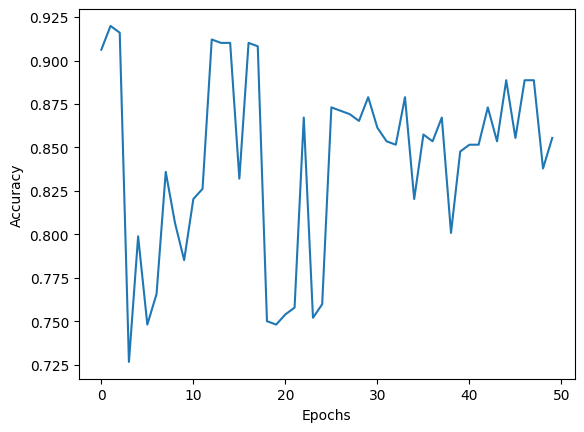

Train Accuracy : 0.85546875
Test Accuracy  : 0.7719298245614035


In [28]:
# 2. Train the model FIRST (this sets self.w and self.b)
perceptron_neuron_model.fit(X_train, y_train, epochs = 50);

# 3. Now make predictions
y_pred_train = perceptron_neuron_model.predict(X_train)
y_pred_test = perceptron_neuron_model.predict(X_test)

train_accuracy = perceptron_neuron_model.accuracy(y_pred_train, y_train)
test_accuracy = perceptron_neuron_model.accuracy(y_pred_test, y_test)

print("Train Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

# Checkpointing

In [29]:
class Perceptron:

    def __init__(self):
        self.w = None
        self.b = None

    def model(self, x):
        # Calculates dot product w * x and checks threshold b
        return 1 if (np.dot(self.w, x) >= self.b) else 0;

    def predict(self, X):
        Y = []
        for x in X:
            result = self.model(x)
            Y.append(result)
        return np.array(Y)

    def fit(self, X, Y, epochs = 1):

        # Initialize weights with ones and bias with 0
        self.w = np.ones(X.shape[1])
        self.b = 0

        accuracy_dict = {}
        max_accuracy = 0
        max_accuracy_epoch = 0
        wt_matrix = []

        for epoch in range(epochs):
            for x, y in zip(X, Y):
                y_pred = self.model(x)

                # Perceptron Learning Rule updates
                if y == 1 and y_pred == 0:
                    self.w = self.w + x
                    self.b = self.b + 1
                elif y == 0 and y_pred == 1:
                    self.w = self.w - x
                    self.b = self.b - 1

            # (Optional) Track accuracy per epoch
            accuracy_dict[epoch] = self.accuracy(self.predict(X), Y)
            if accuracy_dict[epoch] > max_accuracy:
                max_accuracy = accuracy_dict[epoch]
                max_accuracy_epoch = epoch
                chkptw = self.w
                chkptb = self.b

        # Set final parameters to best checkpoint (optional best practice)
        self.w = chkptw
        self.b = chkptb

        print(f"Max Accuracy: {max_accuracy * 100:.2f}% achieved at Epoch: {max_accuracy_epoch+1}")
        plt.plot(accuracy_dict.values());
        plt.xlabel("Epochs");
        plt.ylabel("Accuracy");
        plt.show();

    def accuracy(self, Y_pred, Y_true):
        # Uses scikit-learn's accuracy_score or simple numpy mean
        return accuracy_score(Y_true, Y_pred)

Max Accuracy: 91.99% achieved at Epoch: 2


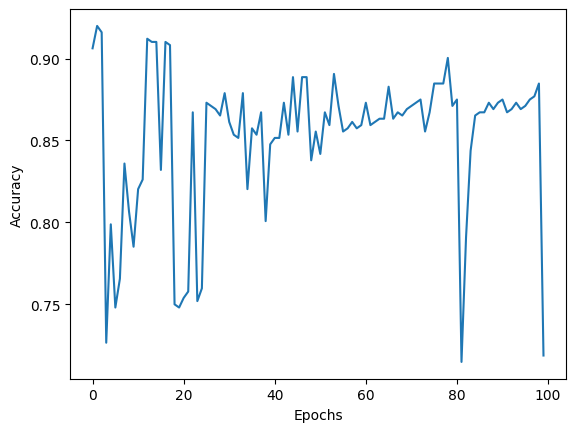

Train Accuracy : 0.919921875
Test Accuracy  : 0.8771929824561403


In [30]:
# 1. Instantiate the model
perceptron_neuron_model = Perceptron()

# 2. Train the model FIRST (this sets self.w and self.b)
perceptron_neuron_model.fit(X_train, y_train, epochs = 100);

# 3. Now make predictions
y_pred_train = perceptron_neuron_model.predict(X_train)
y_pred_test = perceptron_neuron_model.predict(X_test)

train_accuracy = perceptron_neuron_model.accuracy(y_pred_train, y_train)
test_accuracy = perceptron_neuron_model.accuracy(y_pred_test, y_test)

print("Train Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

# Learning Rate

In [31]:
class Perceptron:

    def __init__(self):
        self.w = None
        self.b = None

    def model(self, x):
        # Calculates dot product w * x and checks threshold b
        return 1 if (np.dot(self.w, x) >= self.b) else 0;

    def predict(self, X):
        Y = []
        for x in X:
            result = self.model(x)
            Y.append(result)
        return np.array(Y)

    def fit(self, X, Y, epochs = 1, lr = 1):

        # Initialize weights with ones and bias with 0
        self.w = np.ones(X.shape[1])
        self.b = 0

        accuracy_dict = {}
        max_accuracy = 0
        max_accuracy_epoch = 0
        wt_matrix = []

        for epoch in range(epochs):
            for x, y in zip(X, Y):
                y_pred = self.model(x)

                # Perceptron Learning Rule updates
                if y == 1 and y_pred == 0:
                    self.w = self.w + lr * x
                    self.b = self.b + lr * 1
                elif y == 0 and y_pred == 1:
                    self.w = self.w - lr * x
                    self.b = self.b - lr * 1

            # (Optional) Track accuracy per epoch
            accuracy_dict[epoch] = self.accuracy(self.predict(X), Y)
            if accuracy_dict[epoch] > max_accuracy:
                max_accuracy = accuracy_dict[epoch]
                max_accuracy_epoch = epoch
                chkptw = self.w
                chkptb = self.b

        # Set final parameters to best checkpoint (optional best practice)
        self.w = chkptw
        self.b = chkptb

        print(f"Max Accuracy: {max_accuracy * 100:.2f}% achieved at Epoch: {max_accuracy_epoch+1}")
        plt.plot(accuracy_dict.values());
        plt.ylim([0, 1]);
        plt.xlabel("Epochs");
        plt.ylabel("Accuracy");
        plt.show();

    def accuracy(self, Y_pred, Y_true):
        # Uses scikit-learn's accuracy_score or simple numpy mean
        return accuracy_score(Y_true, Y_pred)

    def plot_weights(self):
        plt.plot(self.w)
        plt.show()

Max Accuracy: 89.06% achieved at Epoch: 6


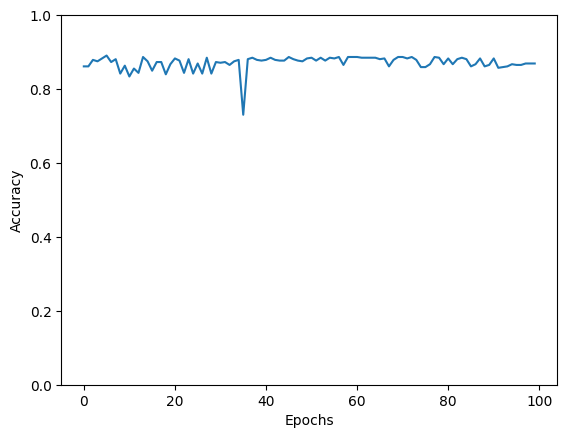

Train Accuracy : 0.890625
Test Accuracy  : 0.8596491228070176


In [32]:
# 1. Instantiate the model
perceptron_neuron_model = Perceptron()

# 2. Train the model FIRST (this sets self.w and self.b)
perceptron_neuron_model.fit(X_train, y_train, epochs = 100, lr = 0.0001);

# 3. Now make predictions
y_pred_train = perceptron_neuron_model.predict(X_train)
y_pred_test = perceptron_neuron_model.predict(X_test)

train_accuracy = perceptron_neuron_model.accuracy(y_pred_train, y_train)
test_accuracy = perceptron_neuron_model.accuracy(y_pred_test, y_test)

print("Train Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

Max Accuracy: 91.41% achieved at Epoch: 425


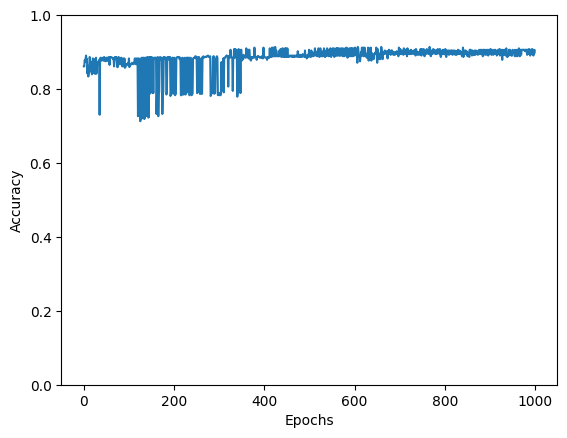

Train Accuracy : 0.9140625
Test Accuracy  : 0.8421052631578947


In [33]:
# 2. Train the model FIRST (this sets self.w and self.b)
perceptron_neuron_model.fit(X_train, y_train, epochs = 1000, lr = 0.0001);

# 3. Now make predictions
y_pred_train = perceptron_neuron_model.predict(X_train)
y_pred_test = perceptron_neuron_model.predict(X_test)

train_accuracy = perceptron_neuron_model.accuracy(y_pred_train, y_train)
test_accuracy = perceptron_neuron_model.accuracy(y_pred_test, y_test)

print("Train Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

Max Accuracy: 93.36% achieved at Epoch: 2217


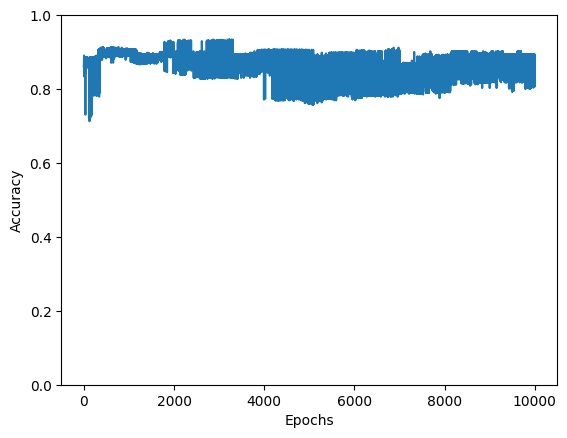

Train Accuracy : 0.93359375
Test Accuracy  : 0.8421052631578947


In [34]:
# 2. Train the model FIRST (this sets self.w and self.b)
perceptron_neuron_model.fit(X_train, y_train, epochs = 10000, lr = 0.0001);

# 3. Now make predictions
y_pred_train = perceptron_neuron_model.predict(X_train)
y_pred_test = perceptron_neuron_model.predict(X_test)

train_accuracy = perceptron_neuron_model.accuracy(y_pred_train, y_train)
test_accuracy = perceptron_neuron_model.accuracy(y_pred_test, y_test)

print("Train Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

Max Accuracy: 93.55% achieved at Epoch: 2180


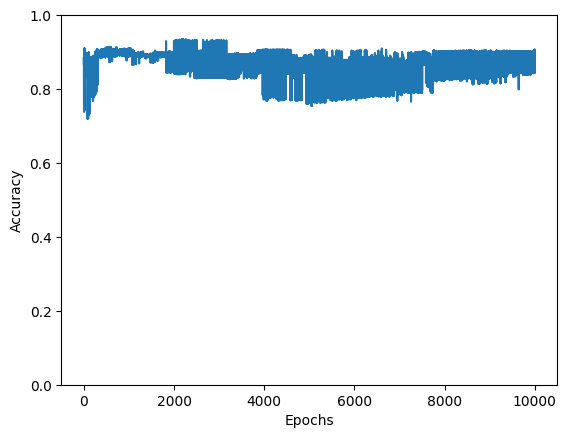

Train Accuracy : 0.935546875
Test Accuracy  : 0.8421052631578947


In [35]:
# 2. Train the model FIRST (this sets self.w and self.b)
perceptron_neuron_model.fit(X_train, y_train, epochs = 10000, lr = 0.01);

# 3. Now make predictions
y_pred_train = perceptron_neuron_model.predict(X_train)
y_pred_test = perceptron_neuron_model.predict(X_test)

train_accuracy = perceptron_neuron_model.accuracy(y_pred_train, y_train)
test_accuracy = perceptron_neuron_model.accuracy(y_pred_test, y_test)

print("Train Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

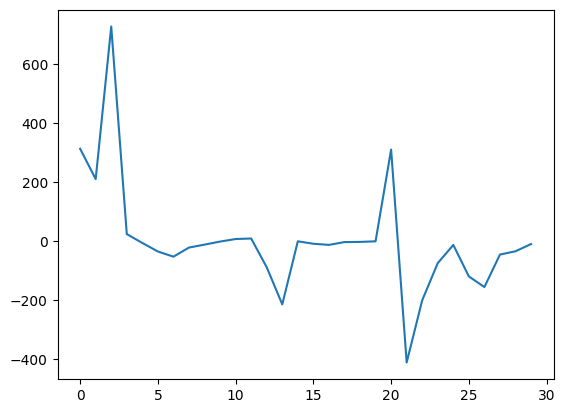

In [36]:
perceptron_neuron_model.plot_weights()

# Weight Animation

In [37]:
class Perceptron:

    def __init__(self):
        self.w = None
        self.b = None

        # Stores weights after every epoch
        self.weight_history = []

    def model(self, x):
        # Calculates dot product w * x and checks threshold b
        return 1 if (np.dot(self.w, x) >= self.b) else 0;

    def predict(self, X):
        Y = []
        for x in X:
            result = self.model(x)
            Y.append(result)
        return np.array(Y)

    def fit(self, X, Y, epochs = 1, lr = 1):

        # Initialize weights with ones and bias with 0
        self.w = np.ones(X.shape[1])
        self.b = 0

        accuracy_dict = {}
        max_accuracy = 0
        max_accuracy_epoch = 0
        wt_matrix = []

        self.weight_history = []

        for epoch in range(epochs):
            for x, y in zip(X, Y):
                y_pred = self.model(x)

                # Perceptron Learning Rule updates
                if y == 1 and y_pred == 0:
                    self.w = self.w + lr * x
                    self.b = self.b + lr * 1
                elif y == 0 and y_pred == 1:
                    self.w = self.w - lr * x
                    self.b = self.b - lr * 1

            # (Optional) Track accuracy per epoch
            self.weight_history.append(self.w.copy())
            accuracy_dict[epoch] = self.accuracy(self.predict(X), Y)
            if accuracy_dict[epoch] > max_accuracy:
                max_accuracy = accuracy_dict[epoch]
                max_accuracy_epoch = epoch
                chkptw = self.w
                chkptb = self.b

        # Set final parameters to best checkpoint (optional best practice)
        self.w = chkptw
        self.b = chkptb

        print(f"Max Accuracy: {max_accuracy * 100:.2f}% achieved at Epoch: {max_accuracy_epoch+1}");
        plt.figure(figsize=(8,5))

        plt.plot(list(accuracy_dict.keys()), list(accuracy_dict.values()), marker='o')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy vs Epoch")
        plt.grid(True)
        plt.show()

    def accuracy(self, Y_pred, Y_true):
        # Uses scikit-learn's accuracy_score or simple numpy mean
        return accuracy_score(Y_true, Y_pred)

    def plot_weights(self):

        plt.figure(figsize=(10,5))
        plt.plot(self.w, marker='o')
        plt.title("Final Learned Weights")
        plt.xlabel("Weight Index")
        plt.ylabel("Weight Value")
        plt.grid(True)
        plt.show()

    def animate_weights(self):

      fig, ax = plt.subplots(figsize=(10,5))

      x = np.arange(len(self.weight_history[0]))

      line, = ax.plot([], [], marker='o')

      ax.set_xlim(0, len(x)-1)

      min_weight = np.min(self.weight_history)
      max_weight = np.max(self.weight_history)

      ax.set_ylim(min_weight-1, max_weight+1)

      ax.set_xlabel("Weight Index")
      ax.set_ylabel("Weight Value")

      def init():

        line.set_data([], [])

        return line,

      def update(frame):

         weights = self.weight_history[frame]

         line.set_data(x, weights)

         ax.set_title(f"Epoch : {frame+1}")

         return line,

      ani = FuncAnimation(
        fig,
        update,
        frames=len(self.weight_history),
        init_func=init,
        interval=500,
        blit=True,
        repeat=False
    )

      plt.close(fig)

      return HTML(ani.to_jshtml())

Max Accuracy: 91.02% achieved at Epoch: 13


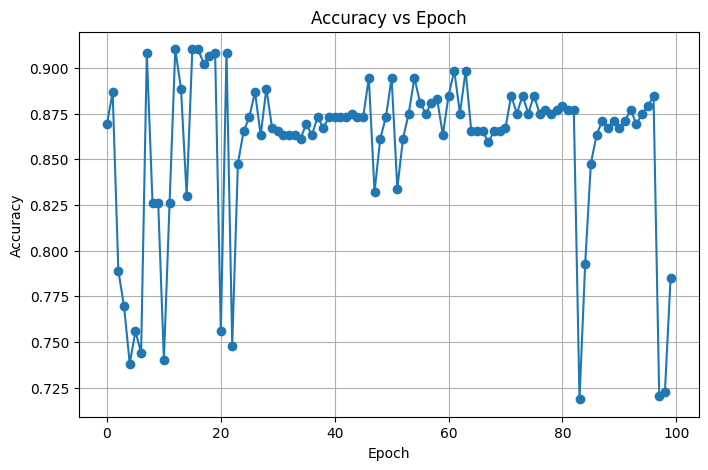

Train Accuracy : 0.91015625
Test Accuracy  : 0.8771929824561403


In [38]:
# 1. Instantiate the model
perceptron_neuron_model = Perceptron()

# 2. Train the model FIRST (this sets self.w and self.b)
perceptron_neuron_model.fit(X_train, y_train, epochs = 100, lr = 0.01);

# 3. Now make predictions
y_pred_train = perceptron_neuron_model.predict(X_train)
y_pred_test = perceptron_neuron_model.predict(X_test)

train_accuracy = perceptron_neuron_model.accuracy(y_pred_train, y_train)
test_accuracy = perceptron_neuron_model.accuracy(y_pred_test, y_test)

print("Train Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

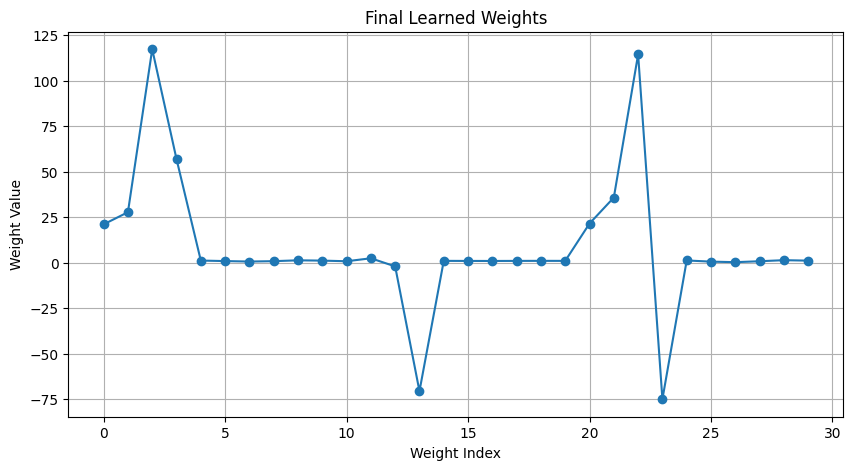

In [39]:
perceptron_neuron_model.plot_weights()

In [40]:
perceptron_neuron_model.animate_weights()